In [4]:
import cv2
import csv
import glob
import time
import numpy as np
import mediapipe as mp
import mp_utils as mu
from matplotlib import pyplot as plt
from imutils.object_detection import non_max_suppression

mp_pose = mp.solutions.pose
#mp_hands = mp.solutions.hands
#mp_face_mesh = mp.solutions.face_mesh
# mp_holistic = mp.solutions.holistic
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

## Portrait Mode <small>(webcam)</small>

In [5]:
# cap = cv2.VideoCapture(0)
# size = (700, 500) # 출력하는 화면 크기
cap = cv2.VideoCapture("BB.mp4")

with mp_pose.Pose(
    static_image_mode=False, 
    model_complexity=1,   # 실시간 웹캠 사용시
    enable_segmentation=True, 
    min_detection_confidence=0.5
) as pose:

    while(cap.isOpened()):
        a, frame = cap.read()
        frame = cv2.resize(frame, (640, 360))
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        image_height, image_width, _ = image.shape # bg_image 미 사용으로 예외
        results = pose.process(image)
        annotated_image = image.copy()

        if results.segmentation_mask is not None: # 사람 유무 확인
            condition = np.stack((results.segmentation_mask,) * 3, axis=-1) > 0.1
            bg_image = np.zeros(image.shape, dtype=np.uint8) # resize 사용으로 예외
            blur_image = image.copy()

            for i in range(2):
                blur_image = cv2.GaussianBlur(blur_image, (17,17), 0)
                annotated_image = np.where(condition, annotated_image, blur_image)

        if results.pose_landmarks is not None: # 사람 
            mp_drawing.draw_landmarks(annotated_image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
        landmark_drawing_spec=mp_drawing_styles.get_default_pose_landmarks_style())

        annotated_image = cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR)

        # resized = cv2.resize(annotated_image, size)
        cv2.imshow("img", annotated_image)

        k = cv2.waitKey(15) & 0xFF
        if k == 27:
            break

cv2.destroyAllWindows()

## Portrait Mode <small>(image)</small>

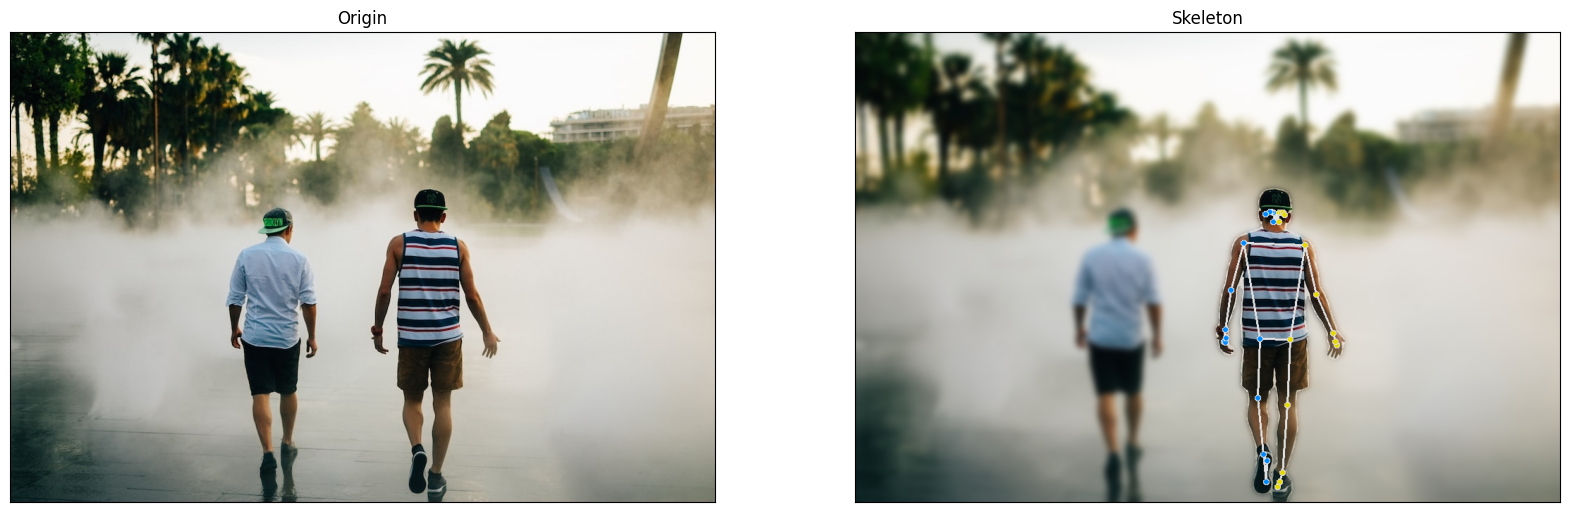

In [6]:
print_skeleton = True
display_skeleton = False
BG_COLOR = (0, 0, 0) # gray
IMAGE_FILES = [".\\image\\persons0.jpg"]
with mp_pose.Pose(static_image_mode=True, model_complexity=2,
  enable_segmentation=True, min_detection_confidence=0.5) as pose:
  for idx, file in enumerate(IMAGE_FILES):
    image = cv2.imread(file)
    image_height, image_width, _ = image.shape
    # Convert the BGR image to RGB before processing.
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = pose.process(image)
    if not results.pose_landmarks:
      continue

    # Draw segmentation on the image.
    # To improve segmentation around boundaries, consider applying a joint
    # bilateral filter to "results.segmentation_mask" with "image".
    annotated_image = image.copy()
    condition = np.stack((results.segmentation_mask,) * 3, axis=-1) > 0.1

    bg_image = np.zeros(image.shape, dtype=np.uint8)
    # bg_image[:] = BG_COLOR
    blur_image = image.copy()
    for i in range(5):
      blur_image = cv2.GaussianBlur(blur_image, (11,11), 0)
    annotated_image = np.where(condition, annotated_image, blur_image)

    # Draw pose landmarks on the image.
    mp_drawing.draw_landmarks(annotated_image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
      landmark_drawing_spec=mp_drawing_styles.get_default_pose_landmarks_style())
    
    plt.figure(figsize = (20,14))
    plt.subplot(1,2,1), plt.imshow(image)
    plt.title('Origin'), plt.xticks([]), plt.yticks([])
    plt.subplot(1,2,2), plt.imshow(annotated_image)
    plt.title('Skeleton'), plt.xticks([]), plt.yticks([])
    plt.show()

    output = '.\\output\\annotated_image.jpg'
    annotated_image = cv2.cvtColor(annotated_image, cv2.COLOR_RGB2BGR)
    cv2.imwrite(output, annotated_image)
